In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: /home/sreethanu/lidc_ldri_dataset_1/lung_cancer_vl_jepa_lidc


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.models.encoder_3d import ViT3DEncoder
from src.models.classification_head import ClassificationHead
from src.utils.config import Config
from src.utils.metrics import compute_classification_metrics


/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
config = Config(str(PROJECT_ROOT / "configs" / "jepa_config.yaml"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
encoder = ViT3DEncoder(
    input_size=tuple(config.get("data.input_shape")[1:]),
    patch_size=tuple(config.get("model.encoder.patch_size")),
    embed_dim=config.get("model.encoder.embed_dim"),
    depth=config.get("model.encoder.depth"),
    num_heads=config.get("model.encoder.num_heads"),
).to(device)

classifier = ClassificationHead(
    embed_dim=config.get("model.encoder.embed_dim"),
    hidden_dims=config.get("model.classifier.hidden_dims"),
    num_classes=2
).to(device)

model = torch.nn.Sequential(encoder, classifier).to(device)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [8]:
from pathlib import Path

finetune_dir = PROJECT_ROOT / "checkpoints" / "finetune"

print("Finetune directory exists:", finetune_dir.exists())

if finetune_dir.exists():
    files = list(finetune_dir.glob("*.pth"))
    print("Checkpoint files found:")
    for f in files:
        print(" -", f.name)

Finetune directory exists: True
Checkpoint files found:
 - final_model.pth


In [7]:
checkpoint_path = PROJECT_ROOT / "checkpoints" / "finetune" / "final_model.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model"])
model.eval()

print("Fine-tuned model loaded.")


Fine-tuned model loaded.


In [9]:
metadata_path = PROJECT_ROOT / "data" / "processed" / "metadata" / "labels.csv"
metadata = pd.read_csv(metadata_path)

print("Total scans:", len(metadata))


Total scans: 883


In [10]:
PATCH_DIR = PROJECT_ROOT / "data" / "processed" / "patches"

all_scan_preds = []
all_scan_labels = []
all_scan_probs = []

with torch.no_grad():

    for idx in tqdm(range(len(metadata))):

        row = metadata.iloc[idx]
        series_uid = row["series_uid"]
        true_label = row["label"]

        series_path = PATCH_DIR / series_uid
        patch_files = list(series_path.glob("*.npz"))

        logits_list = []

        for patch_file in patch_files:
            data = np.load(patch_file)
            volume = torch.tensor(data["patch"], dtype=torch.float32)

            if volume.ndim == 3:
                volume = volume.unsqueeze(0)

            volume = volume.unsqueeze(0).to(device)

            logits = model(volume)
            logits_list.append(logits.squeeze(0))

        if len(logits_list) == 0:
            continue

        avg_logits = torch.stack(logits_list).mean(dim=0)

        probs = torch.softmax(avg_logits, dim=0)
        pred = torch.argmax(probs).item()

        all_scan_preds.append(pred)
        all_scan_labels.append(true_label)
        all_scan_probs.append(probs[1].item())


100%|█████████████████████████████████████████| 883/883 [02:21<00:00,  6.22it/s]


In [11]:
metrics = compute_classification_metrics(
    np.array(all_scan_labels),
    np.array(all_scan_preds),
    np.array(all_scan_probs)
)

print("Final Evaluation Metrics:")
print(metrics)


Final Evaluation Metrics:
{'accuracy': 0.5379388448471121, 'balanced_accuracy': 0.5, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'sensitivity': np.float64(0.0), 'specificity': np.float64(1.0), 'ppv': 0.0, 'npv': np.float64(0.5379388448471121), 'mcc': 0.0, 'roc_auc': 0.5365866873065015, 'pr_auc': 0.5157416288093564}


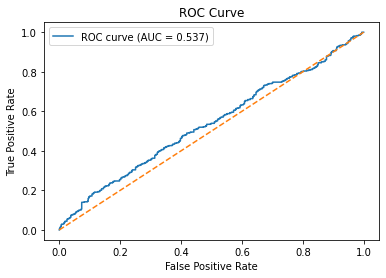

In [12]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_scan_labels, all_scan_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


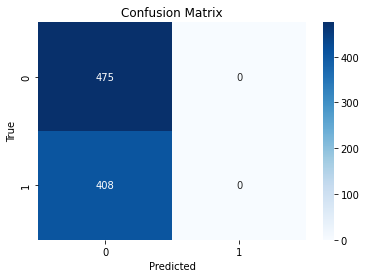

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_scan_labels, all_scan_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [14]:
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)

pd.DataFrame({
    "series_uid": metadata["series_uid"],
    "true_label": all_scan_labels,
    "pred_label": all_scan_preds,
    "prob_malignant": all_scan_probs
}).to_csv(results_dir / "evaluation_results.csv", index=False)

print("Results saved.")


Results saved.


In [18]:
import torch
import torch.nn.functional as F

class ViT3DGradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None

        # 🔥 Hook last transformer layer norm1
        target_layer = model[0].transformer.layers[-1].norm1

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output  # [B, N, D]

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx=None):

        self.model.zero_grad()

        logits = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(logits)

        loss = logits[:, class_idx]
        loss.backward()

        grads = self.gradients  # [B, N, D]
        acts = self.activations  # [B, N, D]

        # Global average pooling over embedding dim
        weights = grads.mean(dim=-1, keepdim=True)  # [B, N, 1]

        cam = (weights * acts).sum(dim=-1)  # [B, N]

        cam = F.relu(cam)
        cam = cam.squeeze(0)

        return cam.detach().cpu().numpy()


In [19]:
print(model[0])


ViT3DEncoder(
  (patch_embed): PatchEmbed3D(
    (proj): Conv3d(1, 768, kernel_size=(16, 16, 16), stride=(16, 16, 16))
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (linear1): Linear(in_features=768, out_features=3072, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=3072, out_features=768, bias=True)
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


In [20]:
gradcam = ViT3DGradCAM(model)

# Load one validation sample
series_uid = metadata.iloc[0]["series_uid"]

patch_path = list((PROJECT_ROOT / "data" / "processed" / "patches" / series_uid).glob("*.npz"))[0]

data = np.load(patch_path)
volume = torch.tensor(data["patch"], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

cam = gradcam.generate(volume, class_idx=1)

print("CAM shape:", cam.shape)


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


CAM shape: (216,)


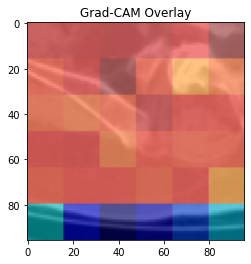

In [21]:
import matplotlib.pyplot as plt

volume_np = volume.squeeze().cpu().numpy()

mid_slice = volume_np[48]
cam_slice = cam.reshape(6,6,6).mean(axis=0)  # approximate reshape
cam_slice = np.repeat(np.repeat(cam_slice, 16, axis=0), 16, axis=1)

plt.imshow(mid_slice, cmap="gray")
plt.imshow(cam_slice, cmap="jet", alpha=0.5)
plt.title("Grad-CAM Overlay")
plt.show()


In [22]:
cam_3d = cam.reshape(6, 6, 6)


In [23]:
import numpy as np
from scipy.ndimage import zoom

cam_upsampled = zoom(cam_3d, (16, 16, 16))  # 6*16 = 96


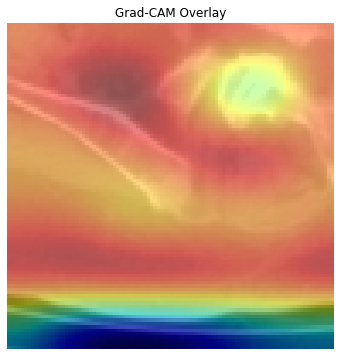

In [24]:
import matplotlib.pyplot as plt

volume_np = volume.squeeze().cpu().numpy()

mid = 48

plt.figure(figsize=(6,6))
plt.imshow(volume_np[mid], cmap="gray")
plt.imshow(cam_upsampled[mid], cmap="jet", alpha=0.5)
plt.title("Grad-CAM Overlay")
plt.axis("off")
plt.show()
